In [4]:
# !python3 train.py --sntp path/to/file.sntp.root --all
# !python3 train.py --sntp path/to/file.sntp.root --models gnn_timing
# !python3 train.py --sntp path/to/file.sntp.root --models cnn_simplified_cross_attention_focal

# MINOS Classifier Evaluation & Visualization Notebook

This notebook provides interactive evaluation, performance plots, event display snapshots, and leaderboard rankings for models trained using `train.py`.

In [5]:
# Setup & Module Imports
import sys
import os
import importlib
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path.cwd()))

# Purge any stale in-memory cached imports for src
for mod in list(sys.modules.keys()):
    if mod == "src" or mod.startswith("src."):
        del sys.modules[mod]

import src
importlib.reload(src)

from src import (
    MINOSMultiViewGraphDataset,
    create_multiview_gnn_dataloaders,
    MODEL_CONFIGS,
    DATASET_CONFIG,
    get_config,
    validate_epoch,
    display_leaderboard,
)

# ─────────────────────────────────────────────────────────────────────
ROOT_FILEPATH = "f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root"  # <-- set this to your MINOS sntp ROOT file
# ─────────────────────────────────────────────────────────────────────
# Only actually read if no cache exists yet for the requested feature_mode.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch Device: {device}")


Using PyTorch Device: cpu


## 1. Model Leaderboard

`model_leaderboard.csv` now holds **only runs on the complete 11,925-event dataset** —
every event with at least one hit in the tracked views.

Earlier runs used a dataset builder that required *both* views to be non-empty, giving
11,694 events. That set is strictly easier: it drops the 231 sparse single-view events,
which are low-energy and hard. Mixing the two families makes runs look better or worse
purely by which filter they used, so the full history has been moved to
`model_leaderboard_archive.csv` and is kept for reference only.

Note on `seed`: `train.py --seed` was added on 2026-08-11. Before that the seed was applied
once globally before the model loop, so only a campaign's *first* model was reproducibly
seeded and the value was never recorded — those rows are left blank rather than guessed.
The train/val split is pinned to `DATASET_CONFIG['random_seed']` in all runs, so every row
below is scored on the same 2,385 validation events.

In [6]:
# Leaderboard for the complete 11,925-event dataset, ranked by ROC-AUC.
LEADERBOARD_CSV = DATASET_CONFIG.get("leaderboard_csv", "model_leaderboard.csv")

leaderboard = pd.read_csv(LEADERBOARD_CSV).sort_values("roc_auc", ascending=False)
leaderboard = leaderboard.reset_index(drop=True)
leaderboard.index += 1
leaderboard.index.name = "Rank"

_cols = ["model_type", "model_name", "num_params", "roc_auc", "f1",
         "accuracy", "val_loss", "n_events", "seed", "timestamp"]
display(leaderboard[[c for c in _cols if c in leaderboard.columns]].style.format({
    "num_params": "{:,.0f}", "roc_auc": "{:.4f}", "f1": "{:.4f}",
    "accuracy": "{:.4f}", "val_loss": "{:.4f}", "n_events": "{:,.0f}",
}).background_gradient(subset=["roc_auc"], cmap="Greens"))

print(f"{len(leaderboard)} runs on the complete dataset "
      f"({int(leaderboard['n_events'].iloc[0]):,} events).")
_arch = Path("model_leaderboard_archive.csv")
if _arch.exists():
    print(f"Archived history (all dataset versions): {len(pd.read_csv(_arch))} rows in {_arch}")

,model_type,model_name,num_params,roc_auc,f1,accuracy,val_loss,n_events,seed,timestamp
Rank,,,,,,,,,,
1,gnn_timing_aux,TimingAwareGNN,"54,939",0.9362,0.9156,0.8734,0.2764,"11,925",42.000000,2026-08-11 14:58:03
2,transformer_hitset_aux,HitSetTransformer,"156,927",0.9354,0.9125,0.8667,0.2752,"11,925",nan,2026-08-11 11:17:30
3,gnn_timing_v3_ablated,TimingAwareGNNV2,"81,674",0.9330,0.9120,0.8616,0.2851,"11,925",nan,2026-08-07 17:02:19
4,gnn_timing_v3,TimingAwareGNNV2,"81,674",0.9329,0.9106,0.8608,0.2976,"11,925",nan,2026-08-07 16:57:29
5,gnn_timing_v1_on_v3,TimingAwareGNN,"53,738",0.9324,0.9131,0.8671,0.2826,"11,925",42.000000,2026-08-11 13:40:12
6,transformer_hitset,HitSetTransformer,"156,927",0.9307,0.9082,0.8583,0.2853,"11,925",nan,2026-08-10 16:58:37


6 runs on the complete dataset (11,925 events).
Archived history (all dataset versions): 44 rows in model_leaderboard_archive.csv


## 2. Select a Model

Set `MODEL_KEY` to any `model_type` in the leaderboard above. Every plot below follows it.

Available: `gnn_timing_aux`, `transformer_hitset_aux`, `gnn_timing_v3`,
`gnn_timing_v3_ablated`, `gnn_timing_v1_on_v3`, `transformer_hitset`.

In [7]:
# ─────────────────────────────────────────────────────────────────────
MODEL_KEY = "gnn_timing_aux"      # <-- set this to any model_type in the leaderboard
# ─────────────────────────────────────────────────────────────────────

_rows = leaderboard[leaderboard["model_type"] == MODEL_KEY]
if _rows.empty:
    raise ValueError(
        f"'{MODEL_KEY}' is not in {LEADERBOARD_CSV}. "
        f"Available: {sorted(leaderboard['model_type'].unique())}"
    )

row = _rows.sort_values("roc_auc", ascending=False).iloc[0]   # best run if repeated
checkpoint_path = row["model_path"]
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint missing: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model_type = checkpoint.get("model_type", MODEL_KEY)

# Prefer the live MODEL_CONFIGS entry: it carries the model_factory needed to
# rebuild the architecture. The checkpoint's copy has callables stripped out.
config = get_config(model_type) if model_type in MODEL_CONFIGS else checkpoint.get("config", {})
saved_metrics = checkpoint.get("best_metrics", {})
history = checkpoint.get("history", None)

print(f"Model      : {MODEL_KEY}  ({config.get('model_name', model_type)})")
print(f"Checkpoint : {checkpoint_path}")
print(f"Params     : {int(row['num_params']):,}")
_seed = row.get("seed", "")
_seed = int(_seed) if str(_seed).strip() not in ("", "nan") else "unrecorded (pre --seed)"
print(f"Git hash   : {checkpoint.get('git_hash', 'n/a')}   seed: {_seed}")
print(f"Feature set: {config.get('feature_mode')}   cache: {config.get('cache_path')}")
print(f"Best epoch : {saved_metrics.get('best_epoch', 'n/a')}")
print(f"Metrics    : ROC-AUC {saved_metrics.get('roc_auc', float('nan')):.4f} | "
      f"F1 {saved_metrics.get('f1', float('nan')):.4f} | "
      f"Acc {saved_metrics.get('accuracy', float('nan')):.4f} | "
      f"thresh {saved_metrics.get('threshold', 0.5):.3f}")

Model      : gnn_timing_aux  (TimingAwareGNN)
Checkpoint : saved_models/gnn_timing_aux_20260811_145803_manual-run.pt
Params     : 54,939
Git hash   : manual-run   seed: 42
Feature set: timing_aux   cache: data/cache/minos_timing_aux.pt
Best epoch : 14
Metrics    : ROC-AUC 0.9362 | F1 0.9156 | Acc 0.8734 | thresh 0.409


## 3. Rebuild Dataset & Model

The dataset is built from **the selected model's own** `feature_mode` and `cache_path`, not
the global default — different models on this leaderboard consume different representations
(`timing`, `timing_aux`, `hitset`). The train/val split uses the fixed
`DATASET_CONFIG['random_seed']`, so this reproduces exactly the validation set the model was
scored on.

In [8]:
# Build from the SELECTED model's feature_mode/cache_path (these differ per model),
# not the global DATASET_CONFIG defaults.
dataset = MINOSMultiViewGraphDataset(
    root_filepath=ROOT_FILEPATH,
    max_events=DATASET_CONFIG["max_events"],
    view_ids=DATASET_CONFIG["view_ids"],
    plane_radius=DATASET_CONFIG["plane_radius"],
    strip_radius=DATASET_CONFIG["strip_radius"],
    feature_mode=config.get("feature_mode", DATASET_CONFIG["feature_mode"]),
    cache_path=config.get("cache_path", DATASET_CONFIG["cache_path"]),
    allow_root_fallback=DATASET_CONFIG.get("allow_root_fallback", True),
    ablate_timing=config.get("ablate_timing", False),
)

train_loader, val_loader, _, _ = create_multiview_gnn_dataloaders(
    dataset,
    batch_size=config.get("batch_size", 32),
    val_split=DATASET_CONFIG.get("val_split", 0.20),
    random_seed=DATASET_CONFIG.get("random_seed", 42),   # fixed: same val set for every model
)
print(f"Dataset: {len(dataset):,} events  |  validation: {len(val_loader.dataset):,}")

# Rebuild the architecture. HeteroData models need metadata(); the timing/hitset
# models use homogeneous Data and take in_channels from x.
sample_graph = dataset[0]
if config.get("is_gnn", False):
    if hasattr(sample_graph, "metadata"):
        metadata = sample_graph.metadata()
        graph_in_channels = sample_graph["view_a"].x.size(-1)
    else:
        metadata = None
        graph_in_channels = sample_graph.x.size(-1)
    model = config["model_factory"](metadata, graph_in_channels)
else:
    model = config["model"]

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device).eval()
print(f"Loaded '{config.get('model_name')}' with {model.get_num_params():,} parameters.")

Dataset: 11,925 events  |  validation: 2,385
Loaded 'TimingAwareGNN' with 54,939 parameters.


## 4. Training & Validation Curves

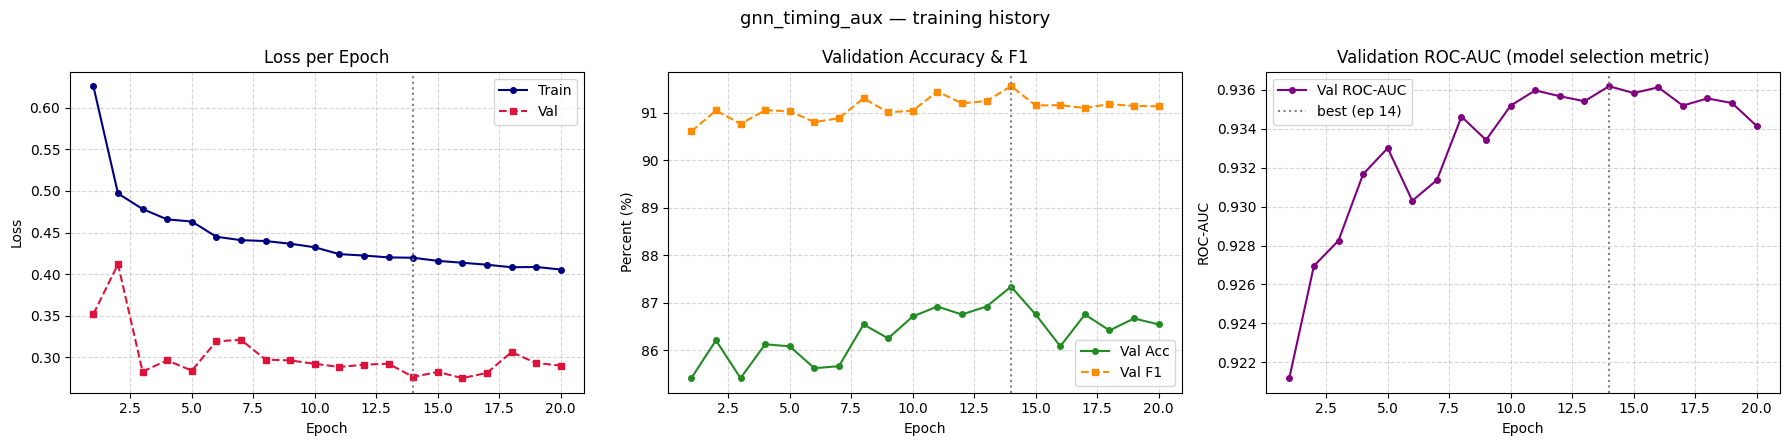

Note: train loss includes the auxiliary per-hit BCE term; val loss is event cross-entropy only, so the two are not directly comparable.


In [9]:
if history is not None and len(history.get("train_loss", [])) > 0:
    epochs = range(1, len(history["train_loss"]) + 1)
    best_ep = saved_metrics.get("best_epoch", None)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(epochs, history["train_loss"], "o-", label="Train", color="navy", ms=4)
    axes[0].plot(epochs, history["val_loss"], "s--", label="Val", color="crimson", ms=4)
    axes[0].set_title("Loss per Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, [a * 100 for a in history["val_acc"]], "o-",
                 label="Val Acc", color="forestgreen", ms=4)
    axes[1].plot(epochs, [f * 100 for f in history["val_f1"]], "s--",
                 label="Val F1", color="darkorange", ms=4)
    axes[1].set_title("Validation Accuracy & F1")
    axes[1].set_ylabel("Percent (%)")

    axes[2].plot(epochs, history["val_auc"], "o-", color="purple", ms=4, label="Val ROC-AUC")
    axes[2].set_title("Validation ROC-AUC (model selection metric)")
    axes[2].set_ylabel("ROC-AUC")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(True, linestyle="--", alpha=0.5)
        if best_ep:
            ax.axvline(best_ep, color="grey", ls=":", lw=1.5,
                       label=f"best (ep {best_ep})" if ax is axes[2] else None)
        ax.legend()

    fig.suptitle(f"{MODEL_KEY} — training history", fontsize=13)
    plt.tight_layout()
    plt.show()

    # The aux-supervised models train against CE + aux BCE, so their train loss is
    # not on the same scale as val loss (which stays event-CE only, deliberately,
    # to keep val_loss comparable across the leaderboard).
    if config.get("feature_mode") in ("timing_aux",) or "aux" in MODEL_KEY:
        print("Note: train loss includes the auxiliary per-hit BCE term; "
              "val loss is event cross-entropy only, so the two are not directly comparable.")
else:
    print("No training history recorded in this checkpoint.")

## 5. Validation Event Displays

Set `HIT_COLOR` to choose what the hit colour encodes:

| value | meaning | available for |
|---|---|---|
| `"predicted"` | model's per-hit **primary-lepton probability** | models with an aux head (`gnn_timing_aux`, `transformer_hitset_aux`) |
| `"truth"` | true primary-lepton **charge fraction** from `thstp` | `hitset` / `timing_aux` feature modes |
| `"charge"` | `log1p` pulse height (the original display) | always |

Unavailable choices fall back automatically with a printed note.

The target is the outgoing **primary lepton** at stdhep index 4, not specifically a muon:
measured over the full file, 1.50% of CC events are νe CC with an electron there (1,332 of
88,783, cross-checked against `mc.inu`). For those the tagged hits are an EM shower, not a track.

Handles both graph layouts on this leaderboard: older HeteroData models carry separate
`view_a`/`view_b` node stores with (plane, strip) coordinates, while `timing`/`timing_aux`/
`hitset` models use a single homogeneous graph where the view is a node *feature* and position
is normalised `(z, tpos)`.

gnn_timing_aux:  ROC-AUC 0.9362 | F1 0.9156 | Acc 0.8734 | threshold 0.409


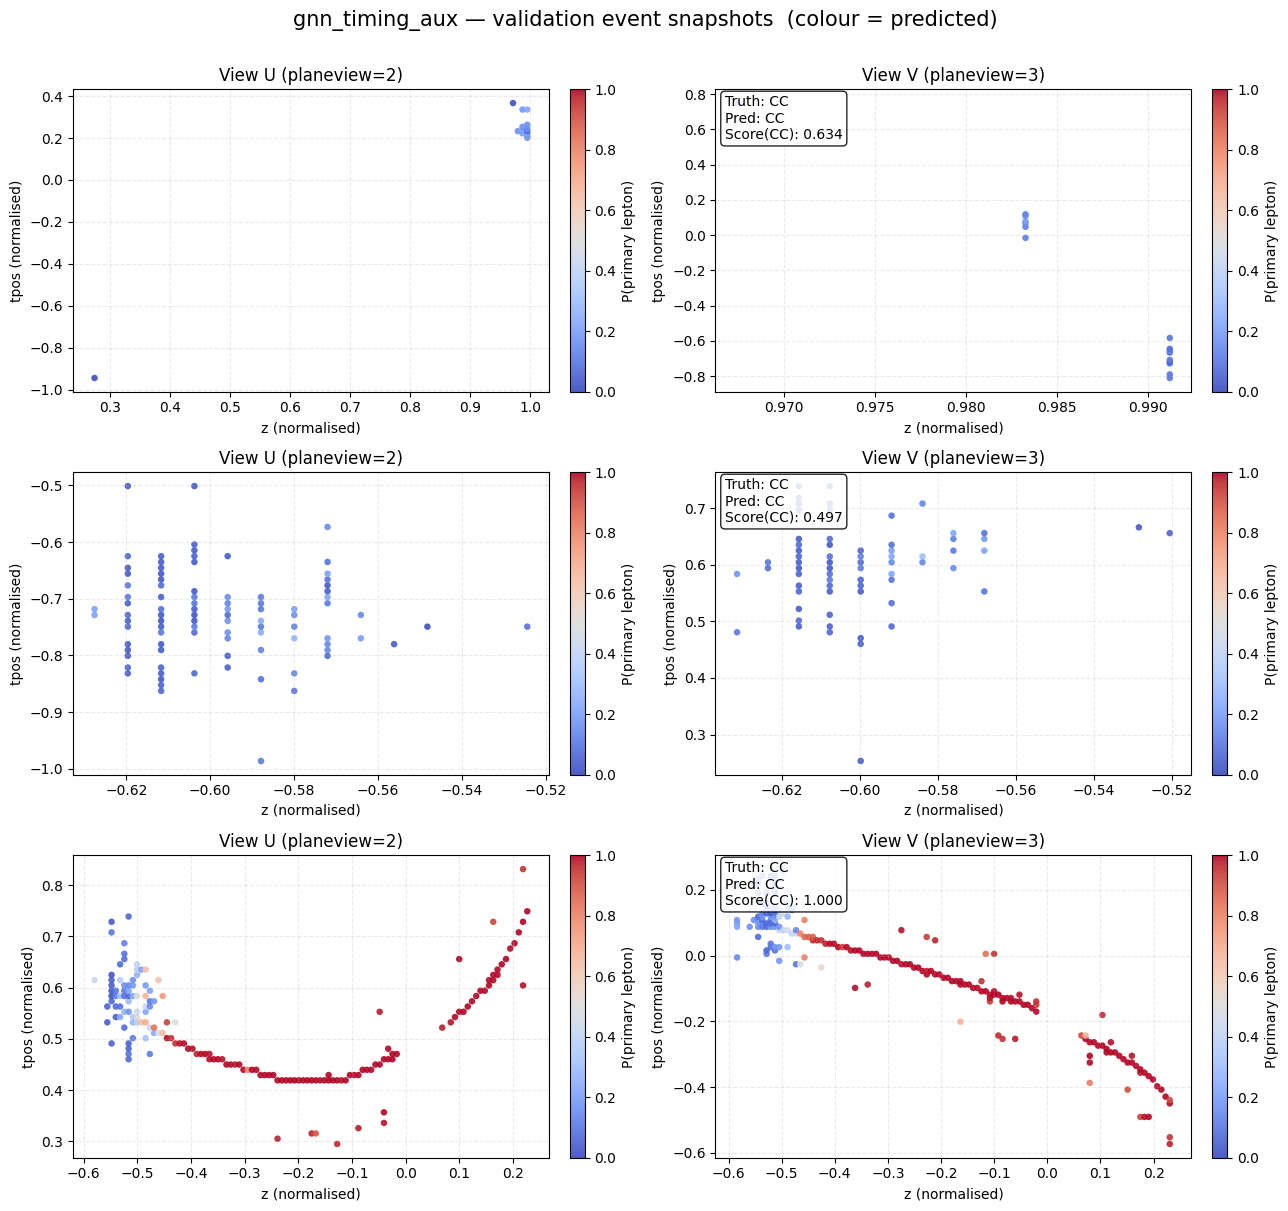

Red = primary-lepton-like, blue = hadronic/other. In a CC event the red hits should form a long thin chain
leaving the shower; in an NC event there should be almost none.


In [10]:
# ─────────────────────────────────────────────────────────────────────
HIT_COLOR = "predicted"      # "predicted" | "truth" | "charge"
# ─────────────────────────────────────────────────────────────────────

from src.dataset import get_hit_lepton_frac, get_has_lepton_truth

# Validation predictions (used by this and every cell below).
val_loss, val_acc, val_metrics, val_probs, val_targets = validate_epoch(
    model, val_loader, device=device
)
opt_thresh = val_metrics.get("threshold", 0.5)
print(f"{MODEL_KEY}:  ROC-AUC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
      f"Acc {val_metrics['accuracy']:.4f} | threshold {opt_thresh:.3f}")

val_subset = val_loader.dataset
if hasattr(val_subset, "indices"):
    sample_graphs = [val_subset.dataset[i] for i in list(val_subset.indices[:3])]
else:
    sample_graphs = [val_subset[i] for i in range(min(3, len(val_subset)))]

_has_head = getattr(model, "aux_weight", 0.0) > 0
_has_truth = get_hit_lepton_frac(sample_graphs[0], required=False) is not None

# Resolve HIT_COLOR against what this model/dataset can actually provide.
_mode = HIT_COLOR
if _mode == "predicted" and not _has_head:
    _mode = "truth" if _has_truth else "charge"
    print(f"note: '{MODEL_KEY}' has no aux head -> colouring by '{_mode}' instead.")
if _mode == "truth" and not _has_truth:
    _mode = "charge"
    print(f"note: feature_mode '{config.get('feature_mode')}' carries no per-hit truth "
          f"-> colouring by 'charge' instead.")

_CMAP = {"predicted": ("coolwarm", 0.0, 1.0, "P(primary lepton)"),
         "truth": ("coolwarm", 0.0, 1.0, "true primary-lepton charge fraction"),
         "charge": ("viridis", None, None, "log1p(charge)")}[_mode]
cmap, vmin, vmax, cbar_label = _CMAP


def _event_score(graph):
    with torch.no_grad():
        logits = model(graph.to(device))
        if isinstance(logits, tuple):      # aux models return (logits, aux) in train mode
            logits = logits[0]
        return float(torch.softmax(logits, dim=1)[0, 1].item())


def _per_hit_pred(graph, n_hits):
    """Per-hit primary-lepton probability aligned with the graph's nodes."""
    with torch.no_grad():
        out = model.predict_hit_lepton_prob(graph.to(device))
    if isinstance(out, tuple):             # transformer: dense [1, N] + mask
        p, m = out
        vals = p[0][m[0]].cpu().numpy()
    else:                                  # GNN: node-indexed
        vals = out.cpu().numpy()
    if len(vals) < n_hits:
        # Transformer truncates to max_hits; mark the unscored tail rather than
        # silently misaligning the colours.
        vals = np.concatenate([vals, np.full(n_hits - len(vals), np.nan)])
    return vals[:n_hits]


# Homogeneous feature layout (timing / timing_aux / hitset):
#   0 pe_east_log, 1 pe_west_log, ..., 4 tpos_norm, 5 z_norm, 6 view_flag
I_PE_E, I_PE_W, I_TPOS, I_Z, I_VIEW = 0, 1, 4, 5, 6
is_hetero = hasattr(sample_graphs[0], "node_types") and "view_a" in sample_graphs[0].node_types

fig, axes = plt.subplots(len(sample_graphs), 2, figsize=(13, 4 * len(sample_graphs)), squeeze=False)

for r, graph in enumerate(sample_graphs):
    score = _event_score(graph)
    truth_lbl = "CC" if int(graph.y.item()) == 1 else "NC"
    pred_lbl = "CC" if score >= opt_thresh else "NC"

    if is_hetero:
        panels = []
        for vn, vid in zip(("view_a", "view_b"), DATASET_CONFIG["view_ids"]):
            c = graph[vn].pos.cpu().numpy()
            panels.append((f"View {vn[-1].upper()} (planeview={vid})",
                           c[:, 1], c[:, 0], graph[vn].x[:, 0].cpu().numpy(),
                           "Strip", "Plane"))
    else:
        x = graph.x.cpu().numpy()
        n = x.shape[0]
        if _mode == "charge":
            cvals = x[:, I_PE_E] + x[:, I_PE_W]
        elif _mode == "truth":
            cvals = get_hit_lepton_frac(graph).cpu().numpy()
        else:
            cvals = _per_hit_pred(graph, n)

        panels = []
        for flag, vid in zip((0.0, 1.0), DATASET_CONFIG["view_ids"]):
            m = x[:, I_VIEW] == flag
            panels.append((f"View {'U' if flag == 0 else 'V'} (planeview={vid})",
                           x[m, I_Z], x[m, I_TPOS], cvals[m],
                           "z (normalised)", "tpos (normalised)"))

    for c, (title, xs, ys, cs, xl, yl) in enumerate(panels):
        ax = axes[r, c]
        if len(xs):
            sc = ax.scatter(xs, ys, c=cs, s=22, cmap=cmap, vmin=vmin, vmax=vmax,
                            alpha=0.9, edgecolor="none")
            fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
        else:
            ax.text(0.5, 0.5, "no hits in this view", ha="center", va="center",
                    transform=ax.transAxes, color="grey")
        ax.set_title(title)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.grid(True, linestyle="--", alpha=0.25)
        if c == 1:
            ax.text(0.02, 0.98, f"Truth: {truth_lbl}\nPred: {pred_lbl}\nScore(CC): {score:.3f}",
                    transform=ax.transAxes, va="top", ha="left",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

fig.suptitle(f"{MODEL_KEY} — validation event snapshots  (colour = {_mode})",
             fontsize=15, y=1.005)
plt.tight_layout()
plt.show()

if _mode in ("predicted", "truth"):
    print("Red = primary-lepton-like, blue = hadronic/other. In a CC event the red hits should "
          "form a long thin chain\nleaving the shower; in an NC event there should be almost none.")

## 6. True Neutrino Energy & Model CC Score Distribution Histograms

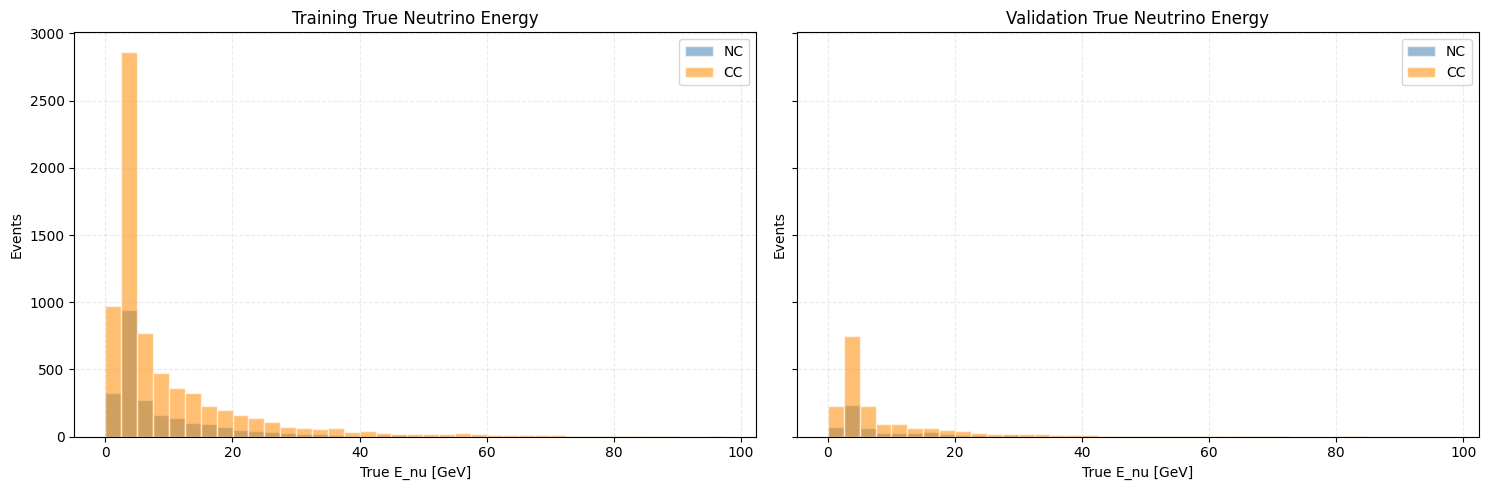

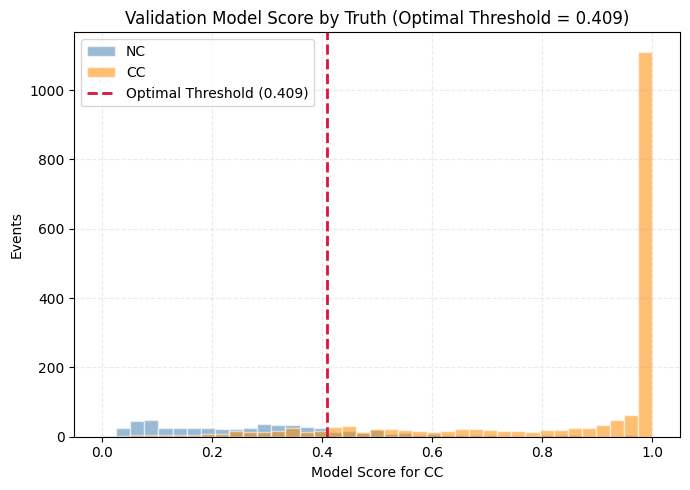

In [11]:
def _split_events(split_dataset):
    if hasattr(split_dataset, 'indices') and hasattr(split_dataset, 'dataset'):
        return [split_dataset.dataset[i] for i in split_dataset.indices]
    return [split_dataset[i] for i in range(len(split_dataset))]

def _event_label(event):
    if hasattr(event, 'y'):
        return int(event.y.item())
    return int(event['label'].item())

def _event_energy(event):
    if hasattr(event, 'true_energy'):
        return float(event.true_energy.item())
    return float(event['true_energy'].item())

def _collect_energies(split_dataset):
    energies_nc = []
    energies_cc = []
    for event in _split_events(split_dataset):
        energy = _event_energy(event)
        if _event_label(event) == 1:
            energies_cc.append(energy)
        else:
            energies_nc.append(energy)
    return np.array(energies_nc, dtype=float), np.array(energies_cc, dtype=float)

train_nc, train_cc = _collect_energies(train_loader.dataset)
val_nc, val_cc = _collect_energies(val_loader.dataset)
all_energy_arrays = [arr for arr in [train_nc, train_cc, val_nc, val_cc] if arr.size > 0]
all_energies = np.concatenate(all_energy_arrays) if all_energy_arrays else np.array([1.0])
max_energy = max(float(all_energies.max()), 1.0)
energy_bins = np.linspace(0.0, max_energy, 40)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, split_name, nc_vals, cc_vals in [
    (axes[0], 'Training', train_nc, train_cc),
    (axes[1], 'Validation', val_nc, val_cc),
]:
    ax.hist(nc_vals, bins=energy_bins, alpha=0.55, color='steelblue', label='NC', edgecolor='white')
    ax.hist(cc_vals, bins=energy_bins, alpha=0.55, color='darkorange', label='CC', edgecolor='white')
    ax.set_title(f'{split_name} True Neutrino Energy')
    ax.set_xlabel('True E_nu [GeV]')
    ax.set_ylabel('Events')
    ax.grid(True, linestyle='--', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

score_bins = np.linspace(0.0, 1.0, 40)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(val_probs[val_targets == 0], bins=score_bins, alpha=0.55, color='steelblue', label='NC', edgecolor='white')
ax.hist(val_probs[val_targets == 1], bins=score_bins, alpha=0.55, color='darkorange', label='CC', edgecolor='white')
ax.axvline(opt_thresh, color="crimson", linestyle="--", linewidth=2, label=f"Optimal Threshold ({opt_thresh:.3f})")
ax.set_title(f"Validation Model Score by Truth (Optimal Threshold = {opt_thresh:.3f})")
ax.set_xlabel('Model Score for CC')
ax.set_ylabel('Events')
ax.grid(True, linestyle='--', alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## 7. True Neutrino Energy vs Model CC Score Scatter Plot

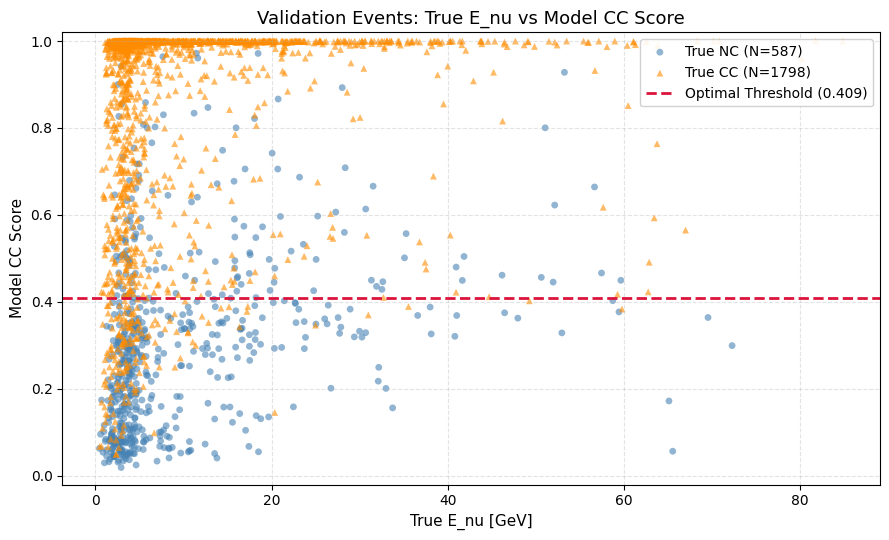

In [12]:
val_events = _split_events(val_loader.dataset)
val_energies = np.array([_event_energy(ev) for ev in val_events])

fig, ax = plt.subplots(figsize=(9, 5.5))
mask_nc = (val_targets == 0)
mask_cc = (val_targets == 1)

ax.scatter(
    val_energies[mask_nc],
    val_probs[mask_nc],
    c='steelblue',
    marker='o',
    alpha=0.6,
    s=24,
    edgecolor='none',
    label=f'True NC (N={mask_nc.sum()})'
)
ax.scatter(
    val_energies[mask_cc],
    val_probs[mask_cc],
    c='darkorange',
    marker='^',
    alpha=0.6,
    s=24,
    edgecolor='none',
    label=f'True CC (N={mask_cc.sum()})'
)

ax.axhline(opt_thresh, color='crimson', linestyle='--', linewidth=2, label=f'Optimal Threshold ({opt_thresh:.3f})')
ax.set_title('Validation Events: True E_nu vs Model CC Score', fontsize=13)
ax.set_xlabel('True E_nu [GeV]', fontsize=11)
ax.set_ylabel('Model CC Score', fontsize=11)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


## 8. Confusion Matrix & Accuracy Breakdown

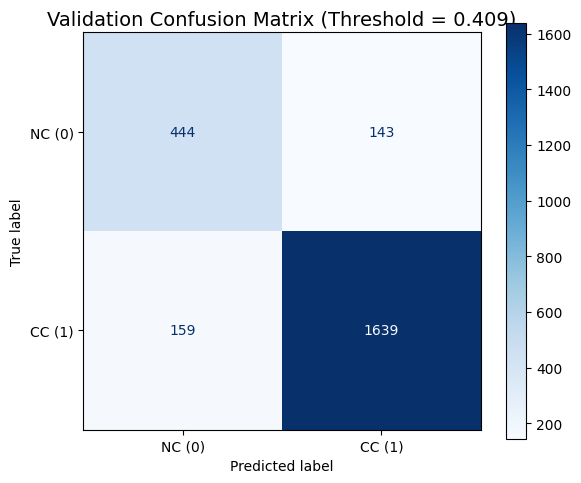

Normalized Recall per Class:
  NC Accuracy: 75.64%
  CC Accuracy: 91.16%


In [13]:
val_preds = (val_probs >= opt_thresh).astype(int)
cm = confusion_matrix(val_targets, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NC (0)', 'CC (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Validation Confusion Matrix (Threshold = {opt_thresh:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

nc_acc = cm[0, 0] / max(1, cm[0].sum()) * 100
cc_acc = cm[1, 1] / max(1, cm[1].sum()) * 100
print('Normalized Recall per Class:')
print(f'  NC Accuracy: {nc_acc:.2f}%')
print(f'  CC Accuracy: {cc_acc:.2f}%')


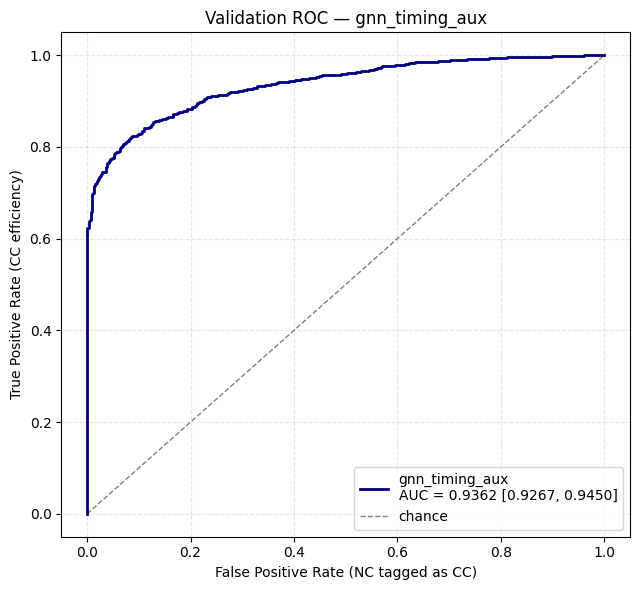

95% CI half-width is +/-0.0091. Differences between models smaller than
this are NOT resolvable from single AUCs -- use scripts/compare_models.py, whose paired
bootstrap is ~3x tighter because models make correlated errors on the same events.


In [14]:
# ── ROC curve, with the bootstrap CI that sets the resolution of this dataset ──
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(val_targets, val_probs)
auc = roc_auc_score(val_targets, val_probs)

rng = np.random.default_rng(0)
idx = rng.integers(0, len(val_targets), size=(2000, len(val_targets)))
boot = np.array([roc_auc_score(val_targets[i], val_probs[i])
                 for i in idx if val_targets[i].min() != val_targets[i].max()])
lo, hi = np.percentile(boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color="navy", lw=2, label=f"{MODEL_KEY}\nAUC = {auc:.4f} [{lo:.4f}, {hi:.4f}]")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="chance")
ax.set_xlabel("False Positive Rate (NC tagged as CC)")
ax.set_ylabel("True Positive Rate (CC efficiency)")
ax.set_title(f"Validation ROC — {MODEL_KEY}")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"95% CI half-width is +/-{(hi - lo) / 2:.4f}. Differences between models smaller than")
print("this are NOT resolvable from single AUCs -- use scripts/compare_models.py, whose paired")
print("bootstrap is ~3x tighter because models make correlated errors on the same events.")

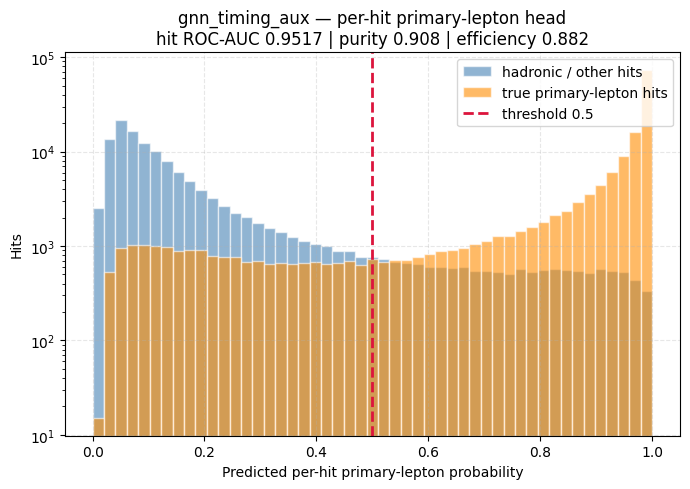

290,106 hits scored; 53.3% are true primary-lepton hits.
Full derived-variable breakdown vs the truth ceiling:
  python scripts/evaluate_hit_head.py saved_models/gnn_timing_aux_20260811_145803_manual-run.pt


In [15]:
# ── Auxiliary per-hit primary-lepton head (aux models only) ──
# This is the output that makes the model checkable against real data: a predicted
# primary-lepton probability per strip, which can be validated on FD cosmics, rock
# muons and muon-removed control samples. An event-level score cannot be checked
# that way.
#
# "Primary lepton", not "muon": the target is stdhep index 4, which is an electron
# in 1.50% of CC events (nu_e CC). Those deposit an EM shower rather than a track.
if getattr(model, "aux_weight", 0.0) > 0:
    from sklearn.metrics import roc_auc_score
    from torch_geometric.utils import to_dense_batch

    probs_all, truth_all = [], []
    for batch in val_loader:
        batch = batch.to(device)
        out = model.predict_hit_lepton_prob(batch)
        has_truth = get_has_lepton_truth(batch).view(-1).bool()

        if isinstance(out, tuple):                    # transformer: dense [B, N] + mask
            p_dense, mask = out
            t_dense, _ = to_dense_batch(get_hit_lepton_frac(batch).unsqueeze(-1),
                                        batch.batch, max_num_nodes=model.max_hits)
            ok = mask & has_truth.view(-1, 1)
            p, t = p_dense[ok], t_dense.squeeze(-1)[ok]
        else:                                         # GNN: node-indexed
            ok = has_truth[batch.batch]               # broadcast per-graph flag to nodes
            p, t = out[ok], get_hit_lepton_frac(batch)[ok]

        # Events without a final-state primary lepton (~0.9%) carry placeholder
        # all-zero labels, not genuine negatives -- excluded above via has_lepton_truth.
        probs_all.append(p.detach().cpu().numpy())
        truth_all.append((t > 0.5).float().detach().cpu().numpy())

    hp, ht = np.concatenate(probs_all), np.concatenate(truth_all)
    hit_auc = roc_auc_score(ht, hp)
    tagged = hp > 0.5
    purity = (tagged & (ht > 0.5)).sum() / max(1, tagged.sum())
    eff = (tagged & (ht > 0.5)).sum() / max(1, (ht > 0.5).sum())

    fig, ax = plt.subplots(figsize=(7, 5))
    bins = np.linspace(0, 1, 50)
    ax.hist(hp[ht < 0.5], bins=bins, alpha=0.6, color="steelblue",
            label="hadronic / other hits", edgecolor="white")
    ax.hist(hp[ht > 0.5], bins=bins, alpha=0.6, color="darkorange",
            label="true primary-lepton hits", edgecolor="white")
    ax.axvline(0.5, color="crimson", ls="--", lw=2, label="threshold 0.5")
    ax.set_yscale("log")
    ax.set_xlabel("Predicted per-hit primary-lepton probability")
    ax.set_ylabel("Hits")
    ax.set_title(f"{MODEL_KEY} — per-hit primary-lepton head\n"
                 f"hit ROC-AUC {hit_auc:.4f} | purity {purity:.3f} | efficiency {eff:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"{len(ht):,} hits scored; {ht.mean():.1%} are true primary-lepton hits.")
    print("Full derived-variable breakdown vs the truth ceiling:")
    print(f"  python scripts/evaluate_hit_head.py {checkpoint_path}")
else:
    print(f"'{MODEL_KEY}' has no auxiliary hit head (aux_weight = 0).")
    print("Models with one: gnn_timing_aux, transformer_hitset_aux.")